# How Big Are Protected Areas?

The percentage of land protected, often presented on its own, doesn't tell the whole story as it hides the fragmentation of the protected areas. Fewer but larger areas are preferred over many small ones as smaller areas have proportionally more 'edge effects' and biodiversity loss.

In this notebook, I explore and visualize the size distributions of protected areas.

**Data.** UNEP-WCMC and IUCN (2026), *Protected Planet: The World Database on Protected Areas
(WDPA) and World Database on Other Effective Area-based Conservation Measures (WD-OECM)*,
March 2026, Cambridge, UK. Available at [protectedplanet.net](https://www.protectedplanet.net).

The full download is far too large to commit here. See [`data/README.md`](../data/README.md)
for how to fetch it.


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from style import use_report_style

use_report_style()

In [34]:
areas = pd.read_csv(
    "../data/protected_areas.csv",
    usecols=["PRNT_ISO3", "GIS_AREA"],
    low_memory=False,
)

print(f"{len(areas):,} protected areas")
areas.head()

321,854 protected areas


,GIS_AREA,PRNT_ISO3
0,14.587808,ATG
1,3.833094,ATG
2,217.931016,ARG
3,90.746053,ARG
4,5368.384077,ARG


## Choosing countries

Ten countries is the ceiling since the plot quickly becomes overcrowded beyond that. I picked ten that differ as much as possible from each other: Finland, Brazil, Indonesia, Costa Rica, Kenya, South Africa, Japan, Australia, Canada and the United States.

The rows are ordered by median so that comparisons are easier to make and values easier to read.


In [37]:
countries = ["FIN", "BRA", "IDN", "CRI", "KEN", "ZAF", "JPN", "AUS", "CAN", "USA"]

selected = areas[areas["PRNT_ISO3"].isin(countries)]

order = (
    selected.groupby("PRNT_ISO3")["GIS_AREA"]
    .median()
    .sort_values(ascending=False)
    .index
)

selected.groupby("PRNT_ISO3")["GIS_AREA"].describe()[["count", "50%", "max", "min"]]

,count,50%,max,min
PRNT_ISO3,,,,
AUS,11901.0,0.973483,6.849559e+05,5.112053e-06
BRA,3873.0,7.405736,4.038442e+05,1.023443e-04
CAN,17536.0,0.748083,3.194005e+05,1.225291e-08
CRI,169.0,25.737929,1.063320e+05,3.211577e-02
FIN,19657.0,0.058018,3.516014e+03,1.007897e-04
IDN,688.0,34.363144,3.355285e+04,7.270870e-05
JPN,7186.0,1.211224,1.156892e+05,5.840262e-05
KEN,411.0,24.331610,1.338053e+04,3.527870e-03
USA,51189.0,0.273261,1.508851e+06,5.592145e-09


Clearly the smallest areas are errors (just a few square millimeters).

In [36]:
before = len(selected)
selected = selected[selected["GIS_AREA"].notna()]
missing = before - len(selected)

tiny = (selected["GIS_AREA"] < 1e-6).sum()
selected = selected[selected["GIS_AREA"] >= 1e-6]

print(f"dropped {missing:,} rows with missing area and {tiny} with areas smaller than 1 m^2")

dropped 387 rows with missing area and 15 with areas smaller than 1 m^2


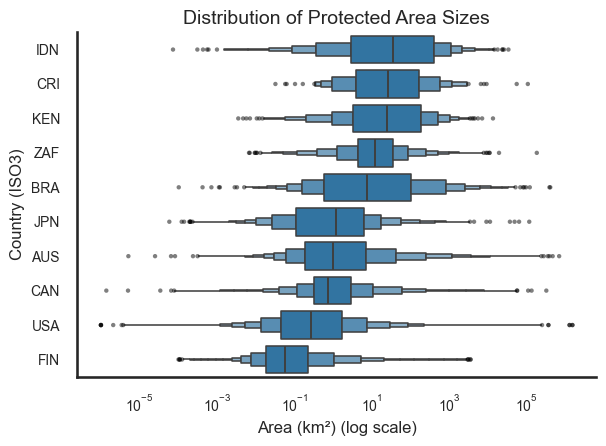

In [24]:
sns.set_style("white")
sns.set_context("talk")

sns.boxenplot(
    data=selected,
    y="PRNT_ISO3",
    x="GIS_AREA",
    order=order,
    flier_kws={"s": 10, "alpha": 0.5, "facecolor": "black", "edgecolor": "none"},
)

plt.xscale("log")
plt.title("Distribution of Protected Area Sizes", fontsize=14)
plt.xlabel("Area (km²) (log scale)", fontsize=12)
plt.ylabel("Country (ISO3)", fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=10)
plt.tick_params(axis="y", which="major", left=False)

sns.despine()
plt.tight_layout()
plt.savefig("../figures/02-protected-area-distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## The results

Protected areas in Indonesia, Costa Rica and Kenya are, on average, larger than in countries such as Finland and USA. However, both the largest and the smallest areas are in the USA. The distribution is much smaller in Kenya, for example. I was a bit surprised to see Finland at the bottom.

It's clear that the distributions are wide, ranging from a few square meters to more than a million km^2. There might still be incorrect values, especially in the lower end, as the values seem very small. The logarithmic scale makes this scale somewhat readable, although difficult to comprehend the real size differences.

**Design notes:** I chose boxen plot instead of box plot simply because box plot hides the tails which I considered important information. Violin plots, on the other hand, would not work well with a logarithmic scale. The log scale itself is not optional as mentioned. Fliers overplotted at first, but reducing marker size and alpha fixed it. They were kept because the largest and smallest values matter here.
